# 14 · Pauli Correlation Encoding para scheduling, paso a paso

Este notebook implementa PCE sobre el **QUBO reducido existente**. Conservamos las variables de asignación y slack GPU; cambiamos el método que busca sus valores binarios.

**Recorrido:** datos → QUBO → spins → observables → ansatz → correlaciones → pérdida → optimización → horario.

Comparamos PCE con $\alpha$ fijo y una **continuación adaptativa inspirada en PB-PCE**, con las mismas semillas y presupuesto máximo de evaluaciones. La referencia exacta se calcula por enumeración, únicamente viable para este ejemplo pequeño. No necesitamos una licencia de Gurobi ni acceso a hardware.

El objetivo incluye energía con PUE fijo y precio efectivo, asignación única, capacidad GPU con slack y suavizado de carga. No representa el MILP completo: quedan fuera despacho exacto renovable/red, baterías y facturación exacta de pico. Los costes mostrados son los del modelo reducido.

## 1. Entorno y reproducibilidad
Ejecutar desde la raíz del repositorio o desde `notebooks/`. Si faltan dependencias, ejecutar en el kernel seleccionado:
```python
%pip install numpy pandas scipy matplotlib pydantic qiskit
```
No instalamos paquetes automáticamente ni modificamos datos del proyecto. La celda final registra versiones.

In [1]:
from pathlib import Path
from itertools import combinations
from math import comb
from time import perf_counter
import sys
import importlib.metadata

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from scipy.optimize import minimize
from qiskit import QuantumCircuit
from qiskit.circuit import ParameterVector
from qiskit.quantum_info import Statevector, Pauli

ROOT = next((p for p in [Path.cwd(), *Path.cwd().parents]
             if (p / "src/quantum/qubo_builder.py").exists()), None)
if ROOT is None:
    raise RuntimeError("Ejecuta el notebook dentro del repositorio.")
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
from src.config import ModelConfig
from src.quantum.qubo_builder import (
    build_scheduling_qubo, QuboPenaltyWeights, qubo_energy,
    decode_qubo_sample, validate_decoded_schedule,
)

ORDER = 2                 # Cambiar a 3 y volver a ejecutar todo para comparar tríos.
LAYERS = 3                # Profundidad independiente del número de variables.
SEEDS = [11, 29, 47]
TOTAL_EVALS = 1200        # Por método y semilla; cuenta llamadas reales a la pérdida.
STAGES = 6
ALPHA_INITIAL = 1.0
ALPHA_FIXED = 8.0
ALPHA_MAX = 128.0
BIN_THRESHOLD = 0.90
SHOTS_PER_BASIS = 4000    # Solo demostración de medida al final; entrenamiento exacto.
assert ORDER in (2, 3)
assert TOTAL_EVALS % STAGES == 0

## 2. Variables de decisión y slack
Reutilizamos el ejemplo de tres trabajos del notebook 13: `j1` y `j2` compiten por la GPU de `c_t4`, mientras `j3` usa `c_v100`. Cada trabajo dura una hora.

$x_{j,c,t}=1$ selecciona un inicio. Para cada cluster-hora con opciones activas, los bits de slack satisfacen:
$$\sum_{j,s}g_j A_{j,s,t}x_{j,c,s}+\sum_b2^b y_{c,t,b}=G_c.$$
Con capacidad 1, basta un bit de slack por cluster-hora. No son nuevas decisiones de negocio: permiten expresar la desigualdad de capacidad como igualdad penalizada.

In [2]:
jobs = pd.DataFrame([
    dict(job_id="j1", category="gpu", duration=1, power=0.010,
         earliest_start=0, latest_start=1, gpu_count_required=1,
         cpu_required=0.0, memory_required_gb=0.0, compatible_clusters=["c_t4"]),
    dict(job_id="j2", category="gpu", duration=1, power=0.015,
         earliest_start=0, latest_start=2, gpu_count_required=1,
         cpu_required=0.0, memory_required_gb=0.0, compatible_clusters=["c_t4"]),
    dict(job_id="j3", category="gpu", duration=1, power=0.008,
         earliest_start=0, latest_start=2, gpu_count_required=1,
         cpu_required=0.0, memory_required_gb=0.0, compatible_clusters=["c_v100"]),
])
clusters = pd.DataFrame([
    dict(cluster_id="c_t4", capacity=1.0, gpu_capacity=1),
    dict(cluster_id="c_v100", capacity=1.0, gpu_capacity=1),
])
hours = [0, 1, 2]
hourly = pd.DataFrame(dict(hour=hours, renewable_available=[0., 0., 0.],
                           grid_price=[30., 100., 40.], pue=[1.2]*3))
config = ModelConfig(delta_t=1.0, pue=1.2)
weights = QuboPenaltyWeights(assignment=200., gpu_capacity=80., peak_smoothing=5000.)
qubo = build_scheduling_qubo(jobs, hourly, clusters, config, weights)
m = qubo.num_variables
variables = pd.DataFrame(qubo.variables).rename_axis("variable")
display(jobs, hourly, variables.fillna(""))
print(f"Asignación: {qubo.metadata['num_assignment_variables']}; "
      f"slack: {qubo.metadata['num_slack_variables']}; total: {m}")

,job_id,category,duration,power,earliest_start,latest_start,gpu_count_required,cpu_required,memory_required_gb,compatible_clusters
0,j1,gpu,1,0.010,0,1,1,0.0,0.0,[c_t4]
1,j2,gpu,1,0.015,0,2,1,0.0,0.0,[c_t4]
2,j3,gpu,1,0.008,0,2,1,0.0,0.0,[c_v100]


,hour,renewable_available,grid_price,pue
0,0,0.0,30.0,1.2
1,1,0.0,100.0,1.2
2,2,0.0,40.0,1.2


,variable_type,job_id,cluster,start,duration,power,gpu_count_required,cpu_required,memory_required_gb,hour,bit,coefficient
variable,,,,,,,,,,,,
0,assignment,j1,c_t4,0.0,1.0,0.01,1.0,0.0,0.0,,,
1,assignment,j1,c_t4,1.0,1.0,0.01,1.0,0.0,0.0,,,
2,assignment,j2,c_t4,0.0,1.0,0.015,1.0,0.0,0.0,,,
3,assignment,j2,c_t4,1.0,1.0,0.015,1.0,0.0,0.0,,,
4,assignment,j2,c_t4,2.0,1.0,0.015,1.0,0.0,0.0,,,
5,assignment,j3,c_v100,0.0,1.0,0.008,1.0,0.0,0.0,,,
6,assignment,j3,c_v100,1.0,1.0,0.008,1.0,0.0,0.0,,,
7,assignment,j3,c_v100,2.0,1.0,0.008,1.0,0.0,0.0,,,
8,gpu_slack,,c_t4,,,,,,,0.0,0.0,1.0


Asignación: 8; slack: 6; total: 14


## 3. Convertir el QUBO a spins (sin cambiar el problema binario)
Usamos $s_i=2z_i-1$, de modo que signo positivo significa bit 1.
$$E(z)=q_0+\sum_iq_i z_i+\sum_{i<j}q_{ij}z_i z_j
=c+\sum_i h_i s_i+\sum_{i<j}J_{ij}s_i s_j.$$
$$J_{ij}=q_{ij}/4,\quad h_i=q_i/2+\frac14\sum_{j\ne i}q_{ij},\quad
c=q_0+\frac12\sum_iq_i+\frac14\sum_{i<j}q_{ij}.$$
La suma de vecinos utiliza cada coeficiente almacenado una sola vez. Partimos del QUBO **ya expandido**, que ha usado $z_i^2=z_i$. Sustituir valores fraccionarios directamente en las restricciones sin expandir daría otra relajación.

In [3]:
def qubo_to_ising(q):
    h = np.zeros(q.num_variables)
    c = float(q.offset)
    for i, value in q.linear.items():
        h[i] += value / 2
        c += value / 2
    edges = list(q.quadratic)
    left = np.array([i for i, j in edges], dtype=int)
    right = np.array([j for i, j in edges], dtype=int)
    J = np.array([q.quadratic[e] / 4 for e in edges])
    for (i, j), value in zip(edges, J):
        h[i] += value
        h[j] += value
        c += value
    return c, h, left, right, J

c, h, left, right, J = qubo_to_ising(qubo)

def spin_energy(s):
    s = np.asarray(s)
    return c + s @ h + np.sum(J * s[..., left] * s[..., right], axis=-1)

scale = max(1.0, np.max(np.abs(h)), np.max(np.abs(J), initial=0.0))
display(pd.DataFrame({"variable": range(m), "h": h}))
print("Offset Ising:", c, "Escala común para entrenamiento:", scale)

,variable,h
0,0,41.3680
1,1,41.7880
2,2,142.0520
3,3,142.6820
4,4,101.6020
5,5,101.0944
6,6,101.4304
7,7,100.8544
8,8,40.0000
9,9,40.0000


Offset Ising: 829.9192 Escala común para entrenamiento: 142.682


## 4. Factibilidad y referencia exacta
Comprobamos por separado:
1. Una asignación por trabajo.
2. Capacidad GPU del horario.
3. Igualdades GPU **incluyendo los bits de slack devueltos**.

Un horario puede ser válido aunque sus bits de slack sean incorrectos. Para esta instancia CPU/memoria son cero y la capacidad de potencia es holgada; añadimos igualmente comprobación de potencia al validar el horario seleccionado.

Enumeramos todos los bitstrings para encontrar el óptimo y verificar la conversión QUBO–Ising. Este control tiene un límite explícito de tamaño y nunca debe usarse para instancias grandes.

In [4]:
A = np.zeros((len(jobs), m))
for row, job in enumerate(jobs.job_id):
    for i, var in enumerate(qubo.variables):
        if var.get("job_id") == job:
            A[row, i] = 1
resource_keys = [(cluster.cluster_id, hour) for cluster in clusters.itertuples() for hour in hours]
G = np.zeros((len(resource_keys), m))
S = np.zeros_like(G)
capacities = np.array([float(clusters.set_index("cluster_id").loc[cluster, "gpu_capacity"])
                       for cluster, hour in resource_keys])
for row, (cluster, hour) in enumerate(resource_keys):
    for i, var in enumerate(qubo.variables):
        if var["cluster"] != cluster:
            continue
        if var["variable_type"] == "assignment":
            if var["start"] <= hour < var["start"] + var["duration"]:
                G[row, i] = var["gpu_count_required"]
        elif var["hour"] == hour:
            S[row, i] = var["coefficient"]

def binary_metrics(bits):
    bits = np.asarray(bits)
    assignment = np.sum(np.abs(A @ bits - 1) > 1e-8)
    capacity = np.sum(G @ bits > capacities + 1e-8)
    slack = np.sum(np.abs((G + S) @ bits - capacities) > 1e-8)
    return dict(assignment_violations=int(assignment), gpu_violations=int(capacity),
                slack_violations=int(slack),
                schedule_feasible=bool(assignment == 0 and capacity == 0),
                encoded_feasible=bool(assignment == 0 and slack == 0))

if m > 18:
    raise ValueError("Enumeración limitada a 18 bits; usa un solver clásico para instancias mayores.")
all_bits = ((np.arange(2**m)[:, None] >> np.arange(m)) & 1).astype(int)
all_spins = 2 * all_bits - 1
energies = spin_energy(all_spins)
# Verificación independiente: evaluación binaria con el helper del repositorio.
np.testing.assert_allclose(energies, [qubo_energy(qubo, b) for b in all_bits], atol=1e-9)
exact_mask = (np.all(all_bits @ A.T == 1, axis=1)
              & np.all(all_bits @ (G + S).T == capacities, axis=1))
assert exact_mask.any(), "La instancia no tiene soluciones factibles."
assert binary_metrics(np.zeros(m, dtype=int))["assignment_violations"] == len(jobs)
assert binary_metrics(np.ones(m, dtype=int))["gpu_violations"] > 0
exact_index = np.flatnonzero(exact_mask)[np.argmin(energies[exact_mask])]
exact_bits = all_bits[exact_index]
exact_energy = float(energies[exact_index])
wrong_slack = exact_bits.copy()
slack_index = next(i for i, v in enumerate(qubo.variables) if v["variable_type"] == "gpu_slack")
wrong_slack[slack_index] ^= 1
assert binary_metrics(wrong_slack)["schedule_feasible"]
assert not binary_metrics(wrong_slack)["encoded_feasible"]
assert np.isclose(energies.min(), exact_energy), "Revisar pesos: el óptimo QUBO es infactible."
print(f"Verificados {len(all_bits):,} bitstrings. Óptimo factible: {exact_energy:.6f}")
display(decode_qubo_sample(qubo, exact_bits))

Verificados 16,384 bitstrings. Óptimo factible: 4.840800


,job_id,assigned_cluster,start_hour,duration,power,gpu_count_required,cpu_required,memory_required_gb,qubo_variable
0,j1,c_t4,0,1,0.010,1.0,0.0,0.0,0
1,j3,c_v100,1,1,0.008,1.0,0.0,0.0,6
2,j2,c_t4,2,1,0.015,1.0,0.0,0.0,4


## 5. Elegir parejas o tríos y asignar observables
Buscamos el menor $n$ tal que $3\binom{n}{k}\ge m$. Es capacidad de **etiquetado**, no garantía de que un ansatz alcance cualquier patrón de signos.

Para 14 variables: parejas necesitan 4 qubits; tríos necesitan 5. En instancias pequeñas un orden mayor puede necesitar **más** qubits.

Intercalamos X, Y y Z por soporte para utilizar las tres familias. El mapping es determinista, pero es otra elección experimental. Qiskit escribe el qubit 0 a la derecha: `IIXX` actúa sobre 0 y 1.

In [5]:
def qubits_required(count, order):
    n = order
    while 3 * comb(n, order) < count:
        n += 1
    return n

def pauli_mapping(count, order):
    n = qubits_required(count, order)
    labels = []
    for support in combinations(range(n), order):
        for axis in "XYZ":
            chars = ["I"] * n
            for qubit in support:
                chars[n - 1 - qubit] = axis
            labels.append("".join(chars))
    return n, labels[:count]

n, labels = pauli_mapping(m, ORDER)
assert len(labels) == m and len(set(labels)) == m
observables = [Pauli(label) for label in labels]
# Matrices pequeñas para acelerar el simulador didáctico; no escalan a registros grandes.
if n > 10:
    raise ValueError("Este notebook usa matrices densas y se limita a 10 qubits.")
observable_matrices = np.array([op.to_matrix() for op in observables])
mapping = variables.copy()
mapping["Pauli (q0 a la derecha)"] = labels
display(mapping.fillna(""))
display(pd.DataFrame({"variables": [m, 100, 500],
                      "qubits_directos": [m, 100, 500],
                      "qubits_parejas": [qubits_required(v, 2) for v in [m,100,500]],
                      "qubits_trios": [qubits_required(v, 3) for v in [m,100,500]]}))

,variable_type,job_id,cluster,start,duration,power,gpu_count_required,cpu_required,memory_required_gb,hour,bit,coefficient,Pauli (q0 a la derecha)
variable,,,,,,,,,,,,,
0,assignment,j1,c_t4,0.0,1.0,0.01,1.0,0.0,0.0,,,,IIXX
1,assignment,j1,c_t4,1.0,1.0,0.01,1.0,0.0,0.0,,,,IIYY
2,assignment,j2,c_t4,0.0,1.0,0.015,1.0,0.0,0.0,,,,IIZZ
3,assignment,j2,c_t4,1.0,1.0,0.015,1.0,0.0,0.0,,,,IXIX
4,assignment,j2,c_t4,2.0,1.0,0.015,1.0,0.0,0.0,,,,IYIY
5,assignment,j3,c_v100,0.0,1.0,0.008,1.0,0.0,0.0,,,,IZIZ
6,assignment,j3,c_v100,1.0,1.0,0.008,1.0,0.0,0.0,,,,XIIX
7,assignment,j3,c_v100,2.0,1.0,0.008,1.0,0.0,0.0,,,,YIIY
8,gpu_slack,,c_t4,,,,,,,0.0,0.0,1.0,ZIIZ


,variables,qubits_directos,qubits_parejas,qubits_trios
0,14,14,4,5
1,100,100,9,7
2,500,500,19,12


## 6. Ansatz y parámetros $\theta$
Cada capa aplica $R_y$ y $R_z$ a todos los qubits, seguida de entrelazamiento CX en cadena. Una capa final de rotaciones permite ajustar las bases locales. $R_z$ permite amplitudes complejas, importantes para explorar observables con Y.

El número de parámetros es $2n(L+1)$, independiente del número de variables binarias. Cambiar precios o penalizaciones cambia la pérdida, no estas puertas. Este ansatz es una elección inicial; no impone factibilidad por construcción.

In [6]:
def build_ansatz(num_qubits, layers):
    params = ParameterVector("theta", 2 * num_qubits * (layers + 1))
    circuit = QuantumCircuit(num_qubits)
    cursor = 0
    for layer in range(layers + 1):
        for qubit in range(num_qubits):
            circuit.ry(params[cursor], qubit)
            circuit.rz(params[cursor + 1], qubit)
            cursor += 2
        if layer < layers:
            for qubit in range(num_qubits - 1):
                circuit.cx(qubit, qubit + 1)
    return circuit, list(params)

ansatz, parameters = build_ansatz(n, LAYERS)
def state_for(theta):
    bound = ansatz.assign_parameters(dict(zip(parameters, theta)))
    return Statevector.from_instruction(bound)

def correlations(theta):
    psi = state_for(theta).data
    return np.einsum("i,aij,j->a", psi.conj(), observable_matrices, psi).real

theta_demo = np.random.default_rng(0).uniform(-np.pi, np.pi, len(parameters))
r_demo = correlations(theta_demo)
reference = [state_for(theta_demo).expectation_value(op).real for op in observables]
np.testing.assert_allclose(r_demo, reference, atol=1e-12)
print(f"{n} qubits; {len(parameters)} ángulos; profundidad {ansatz.depth()}")
print(ansatz.draw(output="text", fold=110))

4 qubits; 32 ángulos; profundidad 15
     ┌──────────────┐┌──────────────┐     ┌──────────────┐ ┌──────────────┐                                  »
q_0: ┤ Ry(theta[0]) ├┤ Rz(theta[1]) ├──■──┤ Ry(theta[8]) ├─┤ Rz(theta[9]) ├─────────────────────────■────────»
     ├──────────────┤├──────────────┤┌─┴─┐└──────────────┘┌┴──────────────┤┌───────────────┐      ┌─┴─┐      »
q_1: ┤ Ry(theta[2]) ├┤ Rz(theta[3]) ├┤ X ├───────■────────┤ Ry(theta[10]) ├┤ Rz(theta[11]) ├──────┤ X ├──────»
     ├──────────────┤├──────────────┤└───┘     ┌─┴─┐      └───────────────┘├───────────────┤┌─────┴───┴─────┐»
q_2: ┤ Ry(theta[4]) ├┤ Rz(theta[5]) ├──────────┤ X ├──────────────■────────┤ Ry(theta[12]) ├┤ Rz(theta[13]) ├»
     ├──────────────┤├──────────────┤          └───┘            ┌─┴─┐      ├───────────────┤├───────────────┤»
q_3: ┤ Ry(theta[6]) ├┤ Rz(theta[7]) ├───────────────────────────┤ X ├──────┤ Ry(theta[14]) ├┤ Rz(theta[15]) ├»
     └──────────────┘└──────────────┘                           └───┘      

## 7. La transformación clásica $\tanh$ y la pérdida
$$u_i=\tanh(\alpha r_i),\qquad
\mathcal L(\theta;\alpha)=\frac{\sum_i h_i u_i+\sum_{i<j}J_{ij}u_i u_j}{\mathrm{scale}}.$$
Quitamos el offset constante y dividimos por una escala común: no cambia el minimizador para un $\alpha$ fijo. El producto $u_i u_j$ se calcula **clásicamente**; no medimos $\langle P_iP_j\rangle$.

No añadimos regularización en este primer experimento. No es una reproducción completa del PCE original. El término de regularización debe estudiarse aparte de las penalizaciones de factibilidad.

Al decodificar usamos $z_i=1$ si $r_i>0$ y 0 en otro caso. El cero exacto se desempata a 0 y se registra como ambiguo. $\alpha$ grande no mejora por sí solo la precisión estadística del signo de $r_i$.

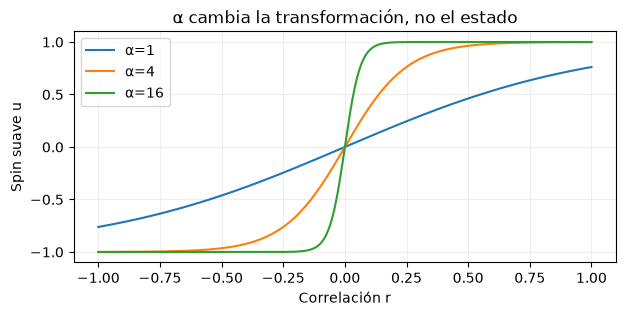

,observable,r,u_alpha_8,bit
0,IIXX,-0.182902,-0.898276,0
1,IIYY,-0.331345,-0.990081,0
2,IIZZ,0.318776,0.987885,1
3,IXIX,0.164913,0.866610,1
4,IYIY,-0.021603,-0.171125,0
5,IZIZ,-0.270103,-0.973792,0
6,XIIX,0.002135,0.017078,1
7,YIIY,0.513374,0.999458,1
8,ZIIZ,0.125008,0.761620,1
9,IXXI,0.229008,0.950028,1


In [7]:
def decode_correlations(r):
    return (np.asarray(r) > 0).astype(int)

def relaxed_loss(r, alpha):
    u = np.tanh(alpha * r)
    return float((h @ u + np.sum(J * u[left] * u[right])) / scale)

r_grid = np.linspace(-1, 1, 401)
fig, ax = plt.subplots(figsize=(7, 3))
for alpha in [1, 4, 16]:
    ax.plot(r_grid, np.tanh(alpha * r_grid), label=f"α={alpha}")
ax.set(xlabel="Correlación r", ylabel="Spin suave u", title="α cambia la transformación, no el estado")
ax.legend(); ax.grid(alpha=.2)
plt.show()
display(pd.DataFrame({"observable": labels, "r": r_demo,
                      "u_alpha_8": np.tanh(8*r_demo), "bit": decode_correlations(r_demo)}))

## 8. Entrenamiento: $\alpha$ fijo frente a continuación adaptativa
Usamos COBYLA y varias semillas. Ambos métodos parten del **mismo $\theta$ por semilla** y tienen el mismo presupuesto máximo total; registramos el consumo real.

En continuación mantenemos $\alpha$ fijo dentro de una etapa y conservamos el $\theta$ final para la siguiente. Entre etapas, identificamos variables con $|u_i|<M$ y usamos la más próxima al umbral para proponer $\alpha'=\operatorname{arctanh}(M)/|r_i|$.

Añadimos límites de incremento (×1.2 a ×2), techo para $\alpha$ y protección frente a correlaciones nulas. **Es una adaptación acotada inspirada en PB-PCE, no una réplica exacta de su algoritmo.** Si todas las variables superan el umbral, mantenemos $\alpha$ y seguimos refinando dentro del presupuesto. Binarización no significa factibilidad.

Guardamos la mejor solución factible observada en **todas las evaluaciones**, no solo el último estado. No aplicamos reparación ni búsqueda local.

In [8]:
def next_alpha(alpha, r, threshold=BIN_THRESHOLD):
    magnitude = np.abs(np.tanh(alpha * r))
    pending = np.flatnonzero(magnitude < threshold)
    if not len(pending) or alpha >= ALPHA_MAX:
        return alpha
    idx = pending[np.argmax(magnitude[pending])]
    target = np.arctanh(threshold) / max(abs(r[idx]), 1e-12)
    return float(min(ALPHA_MAX, max(1.2 * alpha, min(2.0 * alpha, target))))

def train_pce(method, seed):
    rng = np.random.default_rng(seed)
    theta = rng.uniform(-np.pi, np.pi, len(parameters))
    alpha = ALPHA_FIXED if method == "fixed" else ALPHA_INITIAL
    stage_count = 1 if method == "fixed" else STAGES
    budget = TOTAL_EVALS // stage_count
    history, stages = [], []
    best = None
    started = perf_counter()
    for stage in range(stage_count):
        def objective(candidate):
            nonlocal best
            r = correlations(candidate)
            bits = decode_correlations(r)
            metrics = binary_metrics(bits)
            energy = float(spin_energy(2 * bits - 1))
            loss = relaxed_loss(r, alpha)
            history.append(dict(evaluation=len(history)+1, stage=stage,
                                alpha=alpha, loss=loss, energy=energy,
                                min_abs_r=float(np.min(np.abs(r))),
                                binarization=float(np.mean(np.abs(np.tanh(alpha*r)) >= BIN_THRESHOLD)),
                                **metrics))
            if metrics["encoded_feasible"] and (best is None or energy < best["energy"]):
                best = dict(energy=energy, bits=bits.copy(), theta=candidate.copy(),
                            r=r.copy(), alpha=alpha)
            return loss
        result = minimize(objective, theta, method="COBYLA",
                          options={"maxiter": budget, "rhobeg": 0.5, "tol": 1e-6})
        theta = result.x
        r = correlations(theta)  # Evaluación de diagnóstico, registrada aparte.
        stages.append(dict(stage=stage, alpha=alpha, nfev=result.nfev,
                           optimizer_success=bool(result.success), message=str(result.message),
                           loss=relaxed_loss(r, alpha),
                           binarization=float(np.mean(np.abs(np.tanh(alpha*r)) >= BIN_THRESHOLD)),
                           **binary_metrics(decode_correlations(r))))
        if method != "fixed":
            alpha = next_alpha(alpha, r)
    return dict(method=method, seed=seed, best=best, history=pd.DataFrame(history),
                stages=pd.DataFrame(stages), seconds=perf_counter()-started,
                diagnostic_state_evaluations=stage_count)

runs = []
for seed in SEEDS:
    for method in ["fixed", "adaptive"]:
        run = train_pce(method, seed)
        assert len(run["history"]) <= TOTAL_EVALS
        runs.append(run)
        best_value = None if run["best"] is None else round(run["best"]["energy"], 6)
        print(f"{method:8s} seed={seed}: nfev={len(run['history'])}, "
              f"mejor factible={best_value}, {run['seconds']:.1f}s")

fixed    seed=11: nfev=1200, mejor factible=6.6528, 1.3s


adaptive seed=11: nfev=1200, mejor factible=4.9248, 1.2s


fixed    seed=29: nfev=1200, mejor factible=None, 1.4s


adaptive seed=29: nfev=1200, mejor factible=None, 1.2s


fixed    seed=47: nfev=1200, mejor factible=7.6488, 1.4s


adaptive seed=47: nfev=1200, mejor factible=None, 1.4s


## 9. Comparación sobre soluciones binarias
El gap absoluto compara la energía QUBO factible con el óptimo exacto. `NaN` significa que no se encontró una solución factible, no un coste cero. La tasa por evaluación es descriptiva: los intentos consecutivos están correlacionados y **no** son ensayos independientes.

Añadimos muestreo uniforme de bitstrings como referencia sencilla con el mismo número de candidatos; no equivale en tiempo o recursos a una evaluación cuántica. Ninguna comparación aquí demuestra ventaja cuántica. Tres semillas solo sirven de prueba inicial.

,method,seed,evaluations,diagnostic_states,seconds,best_feasible_energy,absolute_gap,feasible_evaluation_fraction,found_feasible
0,fixed,11,1200,1,1.311389,6.6528,1.812,0.719167,True
1,adaptive,11,1200,6,1.224031,4.9248,0.084,0.040000,True
2,fixed,29,1200,1,1.357158,NaN,NaN,0.000000,False
3,adaptive,29,1200,6,1.211047,NaN,NaN,0.000000,False
4,fixed,47,1200,1,1.418366,7.6488,2.808,0.937500,True
5,adaptive,47,1200,6,1.367687,NaN,NaN,0.000000,False
6,random_bits,11,1200,0,NaN,4.9248,0.084,0.000833,True
7,random_bits,29,1200,0,NaN,NaN,NaN,0.000000,False
8,random_bits,47,1200,0,NaN,NaN,NaN,0.000000,False


,feasible_runs,seeds,best_energy,median_gap
method,,,,
adaptive,1,3,4.9248,0.084
fixed,2,3,6.6528,2.310
random_bits,1,3,4.9248,0.084


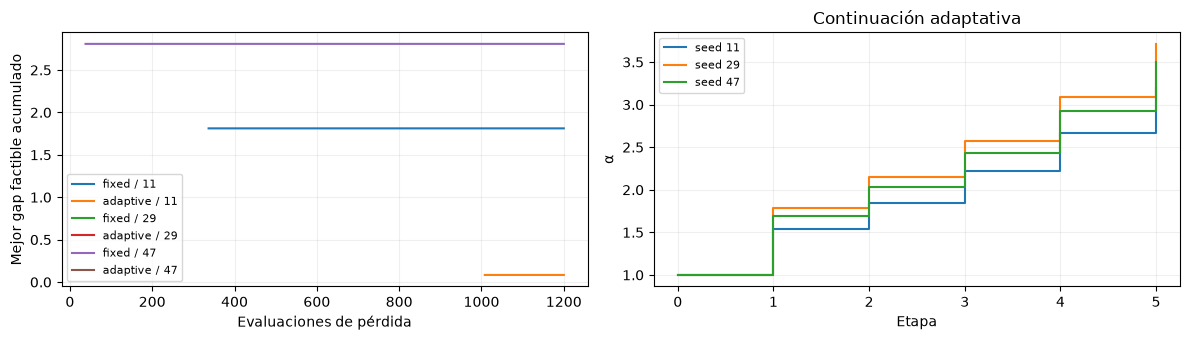

,stage,alpha,nfev,optimizer_success,message,loss,binarization,assignment_violations,gpu_violations,slack_violations,schedule_feasible,encoded_feasible
0,0,1.000000,200,False,Return from COBYLA because the objective funct...,-1.721075,0.000000,1,0,3,False,False
1,1,1.540315,200,False,Return from COBYLA because the objective funct...,-2.368349,0.000000,0,0,4,True,False
2,2,1.848378,200,False,Return from COBYLA because the objective funct...,-2.675139,0.000000,0,0,4,True,False
3,3,2.218054,200,False,Return from COBYLA because the objective funct...,-2.978342,0.142857,0,0,4,True,False
4,4,2.661664,200,False,Return from COBYLA because the objective funct...,-3.382023,0.000000,0,0,2,True,False
5,5,3.193997,200,False,Return from COBYLA because the objective funct...,-3.863074,0.071429,0,0,1,True,False


In [9]:
rows = []
for run in runs:
    hist, best = run["history"], run["best"]
    value = np.nan if best is None else best["energy"]
    rows.append(dict(method=run["method"], seed=run["seed"], evaluations=len(hist),
                     diagnostic_states=run["diagnostic_state_evaluations"],
                     seconds=run["seconds"], best_feasible_energy=value,
                     absolute_gap=value-exact_energy,
                     feasible_evaluation_fraction=hist.encoded_feasible.mean(),
                     found_feasible=best is not None))
for seed in SEEDS:
    rng = np.random.default_rng(seed)
    samples = rng.integers(0, 2, (TOTAL_EVALS, m))
    feasible = (np.all(samples @ A.T == 1, axis=1)
                & np.all(samples @ (G+S).T == capacities, axis=1))
    value = float(np.min(spin_energy(2*samples[feasible]-1))) if feasible.any() else np.nan
    rows.append(dict(method="random_bits", seed=seed, evaluations=TOTAL_EVALS,
                     diagnostic_states=0, seconds=np.nan, best_feasible_energy=value,
                     absolute_gap=value-exact_energy,
                     feasible_evaluation_fraction=feasible.mean(), found_feasible=bool(feasible.any())))
results = pd.DataFrame(rows)
display(results.round(6))
display(results.groupby("method").agg(feasible_runs=("found_feasible", "sum"),
        seeds=("seed", "count"), best_energy=("best_feasible_energy", "min"),
        median_gap=("absolute_gap", "median")))

fig, axes = plt.subplots(1, 2, figsize=(12, 3.5))
for run in runs:
    hist = run["history"]
    feasible_energy = hist.energy.where(hist.encoded_feasible, np.inf).cummin().replace(np.inf, np.nan)
    axes[0].plot(hist.evaluation, feasible_energy-exact_energy,
                 label=f"{run['method']} / {run['seed']}")
    if run["method"] == "adaptive":
        axes[1].step(run["stages"].stage, run["stages"].alpha,
                     where="post", label=f"seed {run['seed']}")
axes[0].set(xlabel="Evaluaciones de pérdida", ylabel="Mejor gap factible acumulado")
axes[1].set(xlabel="Etapa", ylabel="α", title="Continuación adaptativa")
for ax in axes:
    ax.legend(fontsize=8); ax.grid(alpha=.2)
plt.tight_layout(); plt.show()
display(runs[1]["stages"])

## 10. Inspeccionar el horario obtenido y sus componentes
Si PCE no encuentra un horario factible, lo indicamos y mostramos el estado inicial de demostración; nunca lo reemplazamos silenciosamente por la solución exacta. Verificamos además el decodificador del proyecto y capacidad de potencia.

Descomponemos la energía en coste energético, suavizado, penalización de asignación y penalización de slack. El suavizado es un proxy ponderado: el total no debe interpretarse como una factura real en euros.

In [10]:
successful = [run for run in runs if run["best"] is not None]
if successful:
    selected_run = min(successful, key=lambda run: run["best"]["energy"])
    selected = selected_run["best"]
    print("Mejor PCE factible:", selected_run["method"], "seed", selected_run["seed"])
else:
    print("PCE no encontró un bitstring factible con este presupuesto.")
    # Una nueva inicialización sirve solo para mostrar el diagnóstico, no como solución óptima.
    selected = dict(theta=theta_demo, r=r_demo, bits=decode_correlations(r_demo))
    print("Mostramos el estado de demostración, no una solución factible.")
bits = selected["bits"]
schedule = decode_qubo_sample(qubo, bits)
report = validate_decoded_schedule(schedule, jobs, clusters, hours)
power_violations = []
for cluster in clusters.itertuples():
    for hour in hours:
        load = sum(var["power"] * bits[i] for i, var in enumerate(qubo.variables)
                   if var["variable_type"] == "assignment" and var["cluster"] == cluster.cluster_id
                   and var["start"] <= hour < var["start"] + var["duration"])
        if load > cluster.capacity + 1e-8:
            power_violations.append((cluster.cluster_id, hour, load))
if successful:
    assert report["feasible"] and not power_violations
    assert binary_metrics(bits)["encoded_feasible"]
display(schedule)
print("Validación del proyecto:", report, "Excesos de potencia:", power_violations)
print("Validación binaria:", binary_metrics(bits))

facility_load = np.array([sum(var["power"] * bits[i] for i, var in enumerate(qubo.variables)
    if var["variable_type"] == "assignment" and var["start"] <= hour < var["start"]+var["duration"])
    * float(hourly.set_index("hour").loc[hour, "pue"]) for hour in hours])
effective_price = np.where(hourly.renewable_available.to_numpy() > 0,
                           np.minimum(hourly.grid_price.to_numpy(), config.renewable_price),
                           hourly.grid_price.to_numpy())
components = dict(energy=float(facility_load @ effective_price * config.delta_t),
                  smoothing=float(weights.peak_smoothing * (facility_load @ facility_load)),
                  assignment_penalty=float(weights.assignment * np.sum((A @ bits-1)**2)),
                  gpu_slack_penalty=float(weights.gpu_capacity * np.sum(((G+S) @ bits-capacities)**2)))
np.testing.assert_allclose(sum(components.values()), qubo_energy(qubo, bits), atol=1e-8)
display(pd.Series(components, name="valor").to_frame())
display(pd.DataFrame({"cluster_hora": resource_keys, "uso_GPU": G @ bits,
                      "slack_GPU": S @ bits, "capacidad": capacities}))

Mejor PCE factible: adaptive seed 11


,job_id,assigned_cluster,start_hour,duration,power,gpu_count_required,cpu_required,memory_required_gb,qubo_variable
0,j2,c_t4,0,1,0.015,1.0,0.0,0.0,2
1,j1,c_t4,1,1,0.010,1.0,0.0,0.0,1
2,j3,c_v100,2,1,0.008,1.0,0.0,0.0,7


Validación del proyecto: {'feasible': True, 'violations': []} Excesos de potencia: []
Validación binaria: {'assignment_violations': 0, 'gpu_violations': 0, 'slack_violations': 0, 'schedule_feasible': True, 'encoded_feasible': True}


,valor
energy,2.1240
smoothing,2.8008
assignment_penalty,0.0000
gpu_slack_penalty,0.0000


,cluster_hora,uso_GPU,slack_GPU,capacidad
0,"(c_t4, 0)",1.0,0.0,1.0
1,"(c_t4, 1)",1.0,0.0,1.0
2,"(c_t4, 2)",0.0,1.0,1.0
3,"(c_v100, 0)",0.0,1.0,1.0
4,"(c_v100, 1)",0.0,1.0,1.0
5,"(c_v100, 2)",1.0,0.0,1.0


## 11. De valores exactos a shots: tres bases globales
El entrenamiento anterior usa statevector: **no consume shots**. Aquí simulamos el muestreo de un estado seleccionado sin volver a optimizarlo.

En cada base preparamos copias del mismo estado y medimos todos los qubits. Cada shot aporta simultáneamente productos para todas las parejas/tríos de ese eje. Para X aplicamos H antes de medir Z; para Y aplicamos $S^\dagger$ y después H.

Tres bases con $N$ shots requieren $3N$ preparaciones por evaluación. Compartir shots induce dependencia entre estimadores, pero no impide estimar cada media. Mostramos intervalos Wilson del 95% transformados de probabilidad a correlación; son marginales, no simultáneos para todos los observables. Un intervalo que contiene cero indica signo no resuelto con estos shots.

In [11]:
def sample_correlations(theta, shots, seed):
    state = state_for(theta)
    rng = np.random.default_rng(seed)
    estimates, lower, upper = np.zeros(m), np.zeros(m), np.zeros(m)
    for axis in "XYZ":
        rotation = QuantumCircuit(n)
        for qubit in range(n):
            if axis == "Y":
                rotation.sdg(qubit)
            if axis in "XY":
                rotation.h(qubit)
        probabilities = state.evolve(rotation).probabilities()
        outcomes = rng.choice(2**n, size=shots, p=probabilities)
        measured = 1 - 2 * ((outcomes[:, None] >> np.arange(n)) & 1)
        for i, label in enumerate(labels):
            if axis not in label:
                continue
            support = [q for q, char in enumerate(reversed(label)) if char != "I"]
            # Verificar bases y orden de qubits sin depender del azar de los shots.
            possible_bits = (np.arange(2**n)[:, None] >> np.arange(n)) & 1
            parity = np.prod((1-2*possible_bits)[:, support], axis=1)
            np.testing.assert_allclose(probabilities @ parity,
                                       state.expectation_value(observables[i]).real, atol=1e-12)
            products = np.prod(measured[:, support], axis=1)
            estimates[i] = products.mean()
            p = np.mean(products == 1)
            z = 1.95996398454
            denominator = 1 + z*z/shots
            center = (p + z*z/(2*shots))/denominator
            radius = z*np.sqrt(p*(1-p)/shots + z*z/(4*shots*shots))/denominator
            lower[i], upper[i] = 2*(center-radius)-1, 2*(center+radius)-1
    return estimates, lower, upper

r_exact = correlations(selected["theta"])
r_shots, lo, hi = sample_correlations(selected["theta"], SHOTS_PER_BASIS, seed=2026)
shot_table = pd.DataFrame({"Pauli": labels, "exact": r_exact, "shots": r_shots,
                           "CI95_low": lo, "CI95_high": hi,
                           "sign_unresolved": (lo <= 0) & (hi >= 0),
                           "exact_bit": decode_correlations(r_exact),
                           "shot_bit": decode_correlations(r_shots)})
display(shot_table.round(4))
print("Preparaciones:", 3*SHOTS_PER_BASIS)
print("Factibilidad con signos estimados:", binary_metrics(decode_correlations(r_shots)))

,Pauli,exact,shots,CI95_low,CI95_high,sign_unresolved,exact_bit,shot_bit
0,IIXX,-0.4142,-0.4175,-0.4452,-0.3890,False,0,0
1,IIYY,0.3977,0.3935,0.3646,0.4216,False,1,1
2,IIZZ,0.3528,0.3600,0.3308,0.3886,False,1,1
3,IXIX,-0.4626,-0.4465,-0.4738,-0.4184,False,0,0
4,IYIY,-0.4377,-0.4535,-0.4807,-0.4255,False,0,0
5,IZIZ,-0.3862,-0.3885,-0.4167,-0.3596,False,0,0
6,XIIX,-0.3636,-0.3560,-0.3846,-0.3267,False,0,0
7,YIIY,0.2576,0.2360,0.2057,0.2659,False,1,1
8,ZIIZ,-0.1318,-0.1400,-0.1705,-0.1092,False,0,0
9,IXXI,-0.0385,-0.0440,-0.0749,-0.0130,False,0,0


Preparaciones: 12000
Factibilidad con signos estimados: {'assignment_violations': 0, 'gpu_violations': 0, 'slack_violations': 0, 'schedule_feasible': True, 'encoded_feasible': True}


## 12. Qué hemos comprobado y siguientes experimentos

- La conversión binaria a spins coincide en todos los bitstrings del ejemplo.
- La implementación de correlaciones coincide con los observables de Qiskit.
- Reportamos soluciones crudas: el óptimo exacto no inicializa ni repara PCE.
- La factibilidad del horario y la de sus slack se distinguen.
- La descomposición de coste coincide con el QUBO.
- La demostración de shots muestra incertidumbre del signo; no es entrenamiento con ruido ni ejecución en hardware.

**Para ampliar:** comparar `ORDER=2` y `ORDER=3`, profundidad, mapping y varias semillas; después presupuesto igualado y entrenamiento con shots. Antes de escalar, reemplazar enumeración y matrices densas. Un mayor α no garantiza factibilidad ni confianza en las medidas. Ningún resultado aquí establece ventaja sobre un solver clásico ni representa el coste del MILP completo.

Referencias:
- [Sciorilli et al., Towards large-scale quantum optimization solvers with few qubits](https://arxiv.org/html/2401.09421v2).
- [Padín-Martínez et al., Progressive Binarization–PCE, v6](https://arxiv.org/html/2602.17479v6). Nuestra regla añade límites prácticos y no reproduce exactamente el algoritmo publicado.
- [Benchmark of PCE for different optimisation problems](https://arxiv.org/html/2606.18914v4).

In [12]:
display(pd.Series({package: importlib.metadata.version(package)
                   for package in ["numpy", "pandas", "scipy", "matplotlib", "qiskit"]},
                  name="version").to_frame())
print("Python:", sys.version.split()[0])
print("Configuración:", dict(order=ORDER, qubits=n, layers=LAYERS, seeds=SEEDS,
                            budget=TOTAL_EVALS, stages=STAGES, alpha_fixed=ALPHA_FIXED,
                            alpha_initial=ALPHA_INITIAL, alpha_max=ALPHA_MAX,
                            threshold=BIN_THRESHOLD))

,version
numpy,2.5.3
pandas,3.0.6
scipy,1.18.1
matplotlib,3.11.2
qiskit,2.5.2


Python: 3.13.5
Configuración: {'order': 2, 'qubits': 4, 'layers': 3, 'seeds': [11, 29, 47], 'budget': 1200, 'stages': 6, 'alpha_fixed': 8.0, 'alpha_initial': 1.0, 'alpha_max': 128.0, 'threshold': 0.9}
